<a href="https://colab.research.google.com/github/iammarkdelacruz/aimcapstone_identify_patterns_associated_wASD/blob/main/ASD_Child_Screening_Capstone_Steps_3_to_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Machine Learning for Autism Spectrum Disorder Screening in Children. This is part of the an AIM AI/ML capstone exploring whether demographic, developmental, familial, prenatal/perinatal and environmental factors can be used to identify patterns associated with ASD status. The initial goal is prediction and feature analysis rather than establishing causation.

## Capstone Notebook — Steps 3 to 5

**Step 3:** Data Preprocessing, Applied EDA & Feature Engineering  
**Step 4:** Model Implementation & Comparison  
**Step 5:** Critical Thinking, Explainable AI & Bias Auditing

**Dataset:** Thabtah, F. (2017). *Autistic Spectrum Disorder Screening Data for Children*. UCI Machine Learning Repository.  
DOI: `10.24432/C5659W`

> This notebook models **ASD screening classification**, not clinical diagnosis.

## 1. Project Setup

This section installs the required packages, imports libraries, fixes random seeds for reproducibility, and creates folders for model artefacts, tables, figures, and configuration files.

In [ ]:
!pip -q install ucimlrepo xgboost shap fairlearn joblib

In [ ]:
import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.inspection import PartialDependenceDisplay

import shap
import joblib

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

for folder in [
    "models",
    "results",
    "results/figures",
    "results/tables",
    "configs"
]:
    os.makedirs(folder, exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load the UCI ASD Child Screening Dataset

The dataset is retrieved directly from the UCI Machine Learning Repository using dataset ID **419**.

In [ ]:
asd = fetch_ucirepo(id=419)

X_raw = asd.data.features.copy()
y_raw = asd.data.targets.copy()

print("Feature shape:", X_raw.shape)
print("Target shape:", y_raw.shape)

display(X_raw.head())
display(y_raw.head())

Feature shape: (292, 20)
Target shape: (292, 1)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation
0,1,1,0,0,1,1,0,1,0,0,6.0,m,Others,no,no,Jordan,no,5,'4-11 years',Parent
1,1,1,0,0,1,1,0,1,0,0,6.0,m,'Middle Eastern ',no,no,Jordan,no,5,'4-11 years',Parent
2,1,1,0,0,0,1,1,1,0,0,6.0,m,NaN,no,no,Jordan,yes,5,'4-11 years',NaN
3,0,1,0,0,1,1,0,0,0,1,5.0,f,NaN,yes,no,Jordan,no,4,'4-11 years',NaN
4,1,1,1,1,1,1,1,1,1,1,5.0,m,Others,yes,no,'United States',no,10,'4-11 years',Parent


,class
0,NO
1,NO
2,NO
3,NO
4,YES


In [ ]:
print("UCI Metadata:")
print(asd.metadata)

print("\nVariable Definitions:")
display(asd.variables)

UCI Metadata:
{'uci_id': 419, 'name': 'Autistic Spectrum Disorder Screening Data for Children  ', 'repository_url': 'https://archive.ics.uci.edu/dataset/419/autistic+spectrum+disorder+screening+data+for+children', 'data_url': 'https://archive.ics.uci.edu/static/public/419/data.csv', 'abstract': 'Children screening data for autism suitable for classification and predictive tasks ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 292, 'num_features': 20, 'feature_types': ['Integer'], 'demographics': ['\x00', 'Age', 'Gender', 'Ethnicity', 'Nationality'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2017, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C5659W', 'creators': ['Fadi Thabtah'], 'intro_paper': None, 'additional_info': {'summary': "see attached file for variables' description ", 'purpose': None, 'funded_by': None, '

,name,role,type,demographic,description,units,missing_values
0,A1_Score,Feature,Integer,None,None,None,no
1,A2_Score,Feature,Integer, ,None,None,no
2,A3_Score,Feature,Integer,None,None,None,no
3,A4_Score,Feature,Integer,None,None,None,no
4,A5_Score,Feature,Integer,None,None,None,no
5,A6_Score,Feature,Integer,None,None,None,no
6,A7_Score,Feature,Integer,None,None,None,no
7,A8_Score,Feature,Integer,None,None,None,no
8,A9_Score,Feature,Integer,None,None,None,no
9,A10_Score,Feature,Integer,None,None,None,no


## 3. Create a Working DataFrame

Features and target are combined for descriptive analysis. The original target column name is retained and a standardized binary target will be created later.

In [ ]:
target_name = y_raw.columns[0]
df = pd.concat([X_raw, y_raw], axis=1)

print("Dataset dimensions:", df.shape)
print("Target column:", target_name)

display(df.head())

Dataset dimensions: (292, 21)
Target column: class


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation,class
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5,'4-11 years',Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,'Middle Eastern ',no,no,Jordan,no,5,'4-11 years',Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,NaN,no,no,Jordan,yes,5,'4-11 years',NaN,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,NaN,yes,no,Jordan,no,4,'4-11 years',NaN,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,'United States',no,10,'4-11 years',Parent,YES


# STEP 3 — Data Preprocessing, Applied EDA & Feature Engineering

## 4. Initial Data Audit

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         292 non-null    int64  
 1   A2_Score         292 non-null    int64  
 2   A3_Score         292 non-null    int64  
 3   A4_Score         292 non-null    int64  
 4   A5_Score         292 non-null    int64  
 5   A6_Score         292 non-null    int64  
 6   A7_Score         292 non-null    int64  
 7   A8_Score         292 non-null    int64  
 8   A9_Score         292 non-null    int64  
 9   A10_Score        292 non-null    int64  
 10  age              288 non-null    float64
 11  gender           292 non-null    object 
 12  ethnicity        249 non-null    object 
 13  jaundice         292 non-null    object 
 14  autism           292 non-null    object 
 15  country_of_res   292 non-null    object 
 16  used_app_before  292 non-null    object 
 17  result          

In [ ]:
audit_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(dropna=False),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})

display(audit_table)
audit_table.to_csv("results/tables/initial_data_audit.csv")

,dtype,unique_values,missing,missing_pct
A1_Score,int64,2,0,0.00
A2_Score,int64,2,0,0.00
A3_Score,int64,2,0,0.00
A4_Score,int64,2,0,0.00
A5_Score,int64,2,0,0.00
A6_Score,int64,2,0,0.00
A7_Score,int64,2,0,0.00
A8_Score,int64,2,0,0.00
A9_Score,int64,2,0,0.00
A10_Score,int64,2,0,0.00


In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
A1_Score,292.0,NaN,NaN,NaN,0.633562,0.482658,0.0,0.0,1.0,1.0,1.0
A2_Score,292.0,NaN,NaN,NaN,0.534247,0.499682,0.0,0.0,1.0,1.0,1.0
A3_Score,292.0,NaN,NaN,NaN,0.743151,0.437646,0.0,0.0,1.0,1.0,1.0
A4_Score,292.0,NaN,NaN,NaN,0.55137,0.498208,0.0,0.0,1.0,1.0,1.0
A5_Score,292.0,NaN,NaN,NaN,0.743151,0.437646,0.0,0.0,1.0,1.0,1.0
A6_Score,292.0,NaN,NaN,NaN,0.712329,0.453454,0.0,0.0,1.0,1.0,1.0
A7_Score,292.0,NaN,NaN,NaN,0.606164,0.489438,0.0,0.0,1.0,1.0,1.0
A8_Score,292.0,NaN,NaN,NaN,0.496575,0.500847,0.0,0.0,0.0,1.0,1.0
A9_Score,292.0,NaN,NaN,NaN,0.493151,0.500811,0.0,0.0,0.0,1.0,1.0
A10_Score,292.0,NaN,NaN,NaN,0.726027,0.446761,0.0,0.0,1.0,1.0,1.0


## 5. Missing Values

Some historical datasets use symbols such as `?` to represent missing values. These are converted to proper `NaN` values before imputation.

In [ ]:
question_mark_counts = {}

for col in df.columns:
    if df[col].dtype == "object":
        values = df[col].astype(str).str.strip()
        q_count = (values == "?").sum()
        if q_count > 0:
            question_mark_counts[col] = q_count

print("Columns containing '?':")
print(question_mark_counts if question_mark_counts else "None")

df = df.replace("?", np.nan)

missing_table = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2)
})

missing_table = missing_table[
    missing_table["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

display(missing_table)

missing_table.to_csv(
    "results/tables/missing_values.csv"
)

Columns containing '?':
None


,Missing_Count,Missing_Percent
ethnicity,43,14.73
relation,43,14.73
age,4,1.37


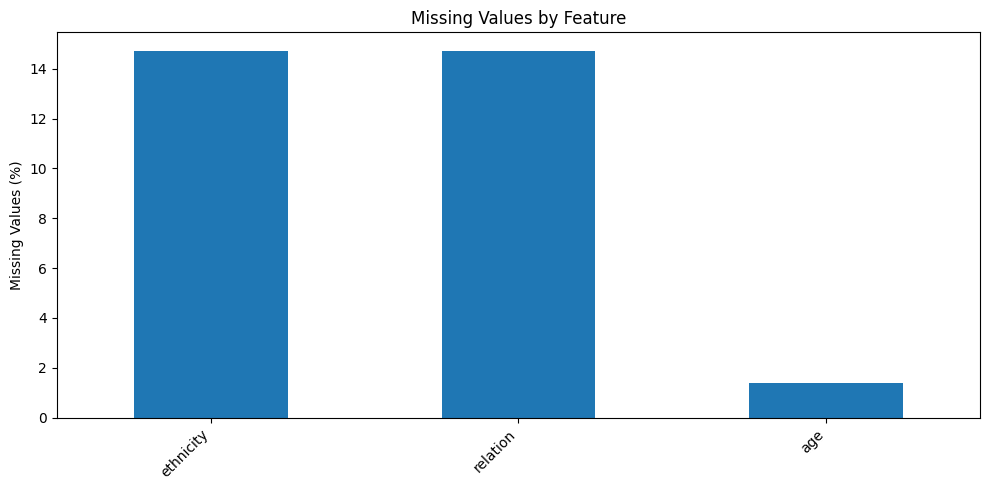

In [ ]:
if len(missing_table) > 0:
    plt.figure(figsize=(10,5))
    missing_table["Missing_Percent"].plot(kind="bar")
    plt.ylabel("Missing Values (%)")
    plt.title("Missing Values by Feature")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("results/figures/missing_values.png", bbox_inches="tight")
    plt.show()
else:
    print("No missing values found after standardization.")

### Missing-value strategy

- Numeric variables will be imputed using the **median**.
- Categorical variables will be imputed using the **most frequent value**.
- All imputation will be fitted on **training data only** to prevent data leakage.

## 6. Duplicate Detection

Exact duplicates are inspected before removal. Identical rows may theoretically represent different children, so duplicates should not be discarded blindly.

In [ ]:
duplicate_count = df.duplicated().sum()
print("Exact duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].head(20))

Exact duplicate rows: 2


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation,class
51,0,0,1,0,1,1,1,0,1,1,...,m,Asian,no,no,India,no,6,'4-11 years',Parent,NO
84,0,0,1,0,1,1,1,0,1,1,...,m,Asian,no,no,India,no,6,'4-11 years',Parent,NO
92,0,0,1,1,1,1,1,1,1,1,...,m,Asian,no,no,India,no,8,'4-11 years',Parent,YES
93,0,0,1,1,1,1,1,1,1,1,...,m,Asian,no,no,India,no,8,'4-11 years',Parent,YES


In [ ]:
# For this capstone, exact duplicate rows are removed after inspection.
df_clean = df.drop_duplicates().copy()

print("Rows before duplicate removal:", len(df))
print("Rows after duplicate removal:", len(df_clean))

Rows before duplicate removal: 292
Rows after duplicate removal: 290


## 7. Standardize the Target

In [ ]:
print("Original target values:")
print(df_clean[target_name].value_counts(dropna=False))

Original target values:
class
NO     150
YES    140
Name: count, dtype: int64


In [ ]:
target_map = {
    "YES": 1, "Yes": 1, "yes": 1,
    "NO": 0,  "No": 0,  "no": 0
}

if df_clean[target_name].dtype == "object":
    df_clean["target"] = df_clean[target_name].map(target_map)
else:
    df_clean["target"] = pd.to_numeric(
        df_clean[target_name],
        errors="coerce"
    )

print("\nStandardized target:")
print(df_clean["target"].value_counts(dropna=False))

if df_clean["target"].isna().sum() > 0:
    raise ValueError(
        "Some target values were not converted. "
        "Inspect df_clean[target_name].value_counts(dropna=False)."
    )

df_clean["target"] = df_clean["target"].astype(int)


Standardized target:
target
0    150
1    140
Name: count, dtype: int64


## 8. Target Distribution

Accuracy is not sufficient on its own if the dataset is imbalanced. The notebook therefore emphasizes ROC-AUC, recall/sensitivity, specificity, F1-score, and PR-AUC.

In [ ]:
target_counts = df_clean["target"].value_counts().sort_index()

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percent": (
        target_counts / target_counts.sum() * 100
    ).round(2)
})

display(target_distribution)

target_distribution.to_csv(
    "results/tables/target_distribution.csv"
)

,Count,Percent
target,,
0,150,51.72
1,140,48.28


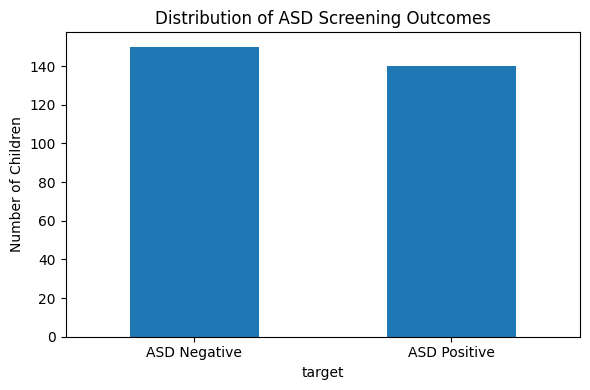

In [ ]:
plt.figure(figsize=(6,4))
target_counts.plot(kind="bar")

plt.xticks(
    [0,1],
    ["ASD Negative", "ASD Positive"],
    rotation=0
)
plt.ylabel("Number of Children")
plt.title("Distribution of ASD Screening Outcomes")
plt.tight_layout()
plt.savefig("results/figures/target_distribution.png", bbox_inches="tight")
plt.show()

## 9. Identify Numeric and Categorical Features

In [ ]:
feature_df = df_clean.drop(
    columns=[target_name, "target"],
    errors="ignore"
)

numeric_cols = (
    feature_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_cols = (
    feature_df
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Numeric features:")
print(numeric_cols)

print("\nCategorical features:")
print(categorical_cols)

Numeric features:
['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'result']

Categorical features:
['gender', 'ethnicity', 'jaundice', 'autism', 'country_of_res', 'used_app_before', 'age_desc', 'relation']


## 10. Inspect Categorical Variables

In [ ]:
for col in categorical_cols:
    print("\n" + "="*60)
    print(col)
    display(
        feature_df[col]
        .value_counts(dropna=False)
        .to_frame("count")
    )


gender


,count
gender,
m,206
f,84



ethnicity


,count
ethnicity,
White-European,108
Asian,44
NaN,43
'Middle Eastern ',27
'South Asian',21
Others,14
Black,14
Latino,8
Hispanic,7



jaundice


...

,count
used_app_before,
no,279
yes,11



age_desc


,count
age_desc,
'4-11 years',290



relation


,count
relation,
Parent,212
NaN,43
Relative,17
'Health care professional',13
Self,4
self,1


## 11. Outlier Analysis

Potential numeric outliers are identified using boxplots and the IQR rule. Values are not removed automatically; statistically unusual values may still be valid.

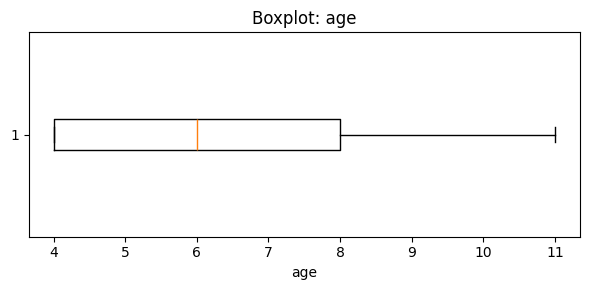

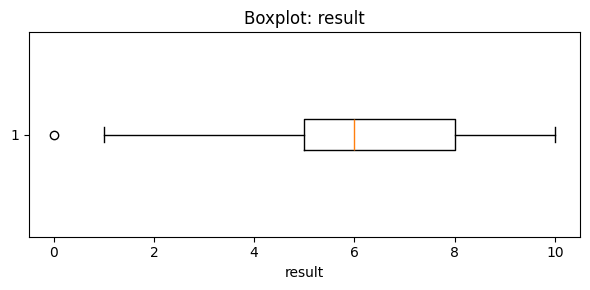

In [ ]:
for col in numeric_cols:
    series = pd.to_numeric(
        feature_df[col],
        errors="coerce"
    ).dropna()

    if series.nunique() <= 2:
        continue

    plt.figure(figsize=(6,3))
    plt.boxplot(series, vert=False)
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
outlier_summary = []

for col in numeric_cols:
    s = pd.to_numeric(
        feature_df[col],
        errors="coerce"
    ).dropna()

    if s.nunique() <= 2:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = (
        (s < lower) |
        (s > upper)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Potential_Outliers": n_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

outlier_df.to_csv(
    "results/tables/outlier_summary.csv",
    index=False
)

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Potential_Outliers
0,age,4.0,8.0,-2.0,14.0,0
1,result,5.0,8.0,0.5,12.5,1


## 12. Behavioural Screening Features

The UCI dataset includes AQ-style behavioural screening items labeled `A1_Score` to `A10_Score`.

In [ ]:
behavior_cols = [
    col for col in feature_df.columns
    if col.lower().startswith("a")
    and "_score" in col.lower()
]

print("Detected behavioural columns:")
print(behavior_cols)

Detected behavioural columns:
['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score']


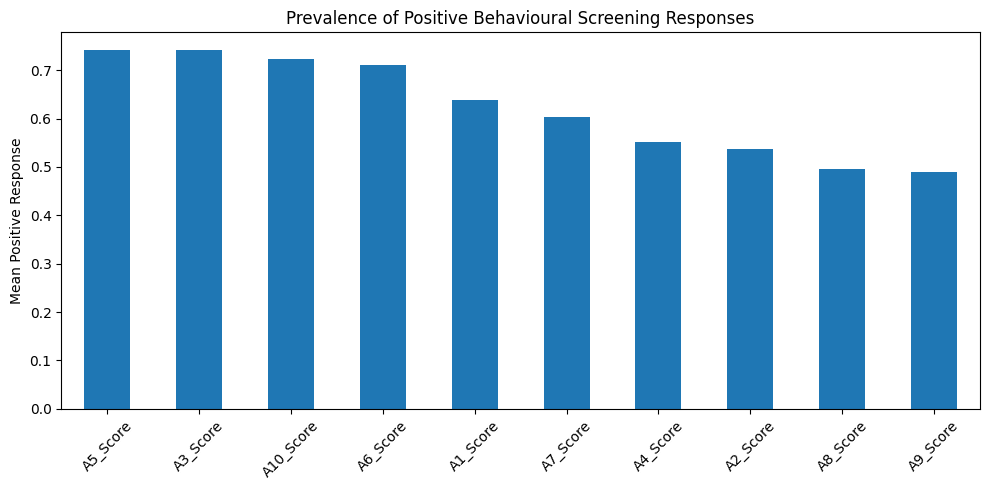

In [ ]:
if behavior_cols:
    behavior_numeric = (
        feature_df[behavior_cols]
        .apply(pd.to_numeric, errors="coerce")
    )

    behavior_means = (
        behavior_numeric
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10,5))
    behavior_means.plot(kind="bar")
    plt.ylabel("Mean Positive Response")
    plt.title("Prevalence of Positive Behavioural Screening Responses")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        "results/figures/behavioral_prevalence.png",
        bbox_inches="tight"
    )
    plt.show()

## 13. Behavioural Responses by ASD Screening Outcome

,ASD_Negative,ASD_Positive
A1_Score,0.453333,0.835714
A2_Score,0.426667,0.657143
A3_Score,0.573333,0.921429
A4_Score,0.280000,0.842857
A5_Score,0.580000,0.914286
A6_Score,0.526667,0.907143
A7_Score,0.473333,0.742857
A8_Score,0.286667,0.721429
A9_Score,0.253333,0.742857
A10_Score,0.533333,0.928571


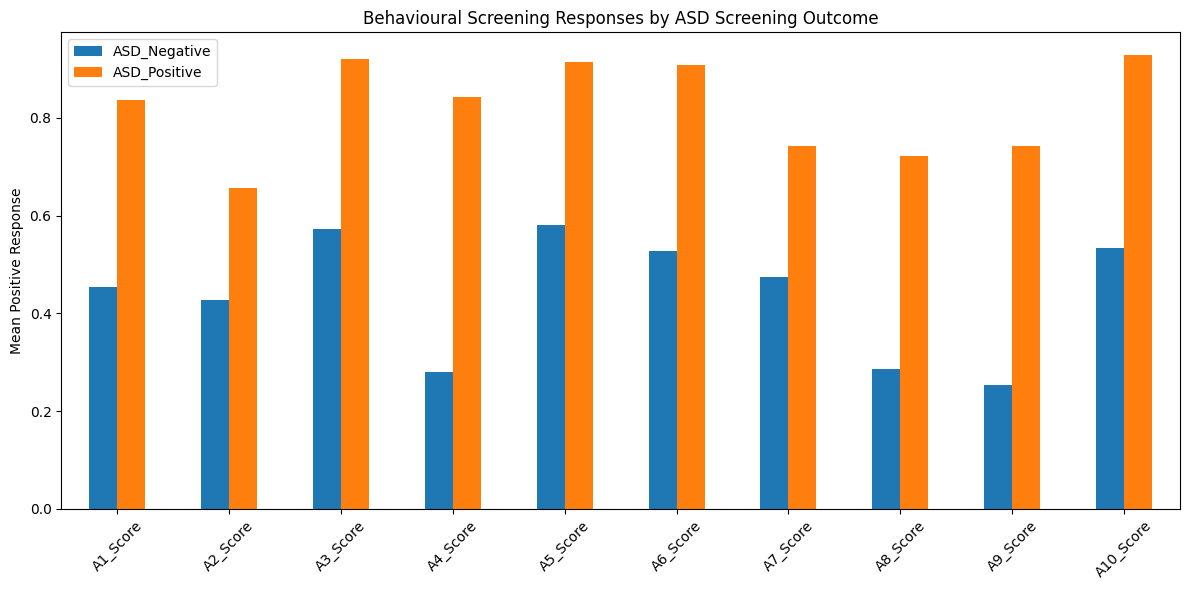

In [ ]:
if behavior_cols:
    behavior_target = df_clean[
        behavior_cols + ["target"]
    ].copy()

    for col in behavior_cols:
        behavior_target[col] = pd.to_numeric(
            behavior_target[col],
            errors="coerce"
        )

    behavior_by_target = (
        behavior_target
        .groupby("target")[behavior_cols]
        .mean()
        .T
    )

    behavior_by_target.columns = [
        "ASD_Negative",
        "ASD_Positive"
    ]

    display(behavior_by_target)

    behavior_by_target.to_csv(
        "results/tables/behavior_by_target.csv"
    )

    behavior_by_target.plot(
        kind="bar",
        figsize=(12,6)
    )

    plt.ylabel("Mean Positive Response")
    plt.title(
        "Behavioural Screening Responses by ASD Screening Outcome"
    )
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        "results/figures/behavior_by_target.png",
        bbox_inches="tight"
    )
    plt.show()

## 14. Categorical Relationships with the Target

target,0,1
gender,,
f,0.547619,0.452381
m,0.504854,0.495146


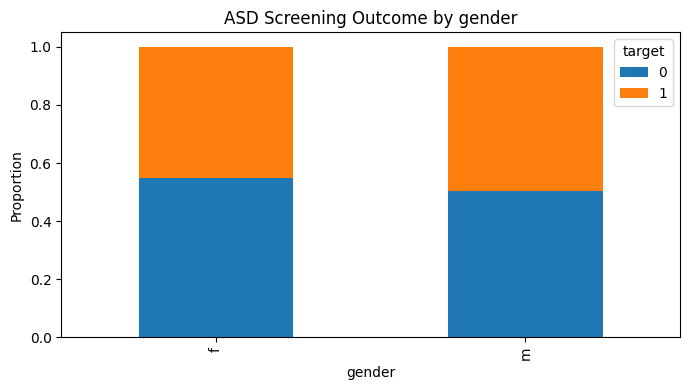

target,0,1
ethnicity,,
'Middle Eastern ',0.703704,0.296296
'South Asian',0.619048,0.380952
Asian,0.522727,0.477273
Black,0.357143,0.642857
Hispanic,0.142857,0.857143
Latino,0.375000,0.625000
Others,0.642857,0.357143
Pasifika,0.500000,0.500000
Turkish,1.000000,0.000000


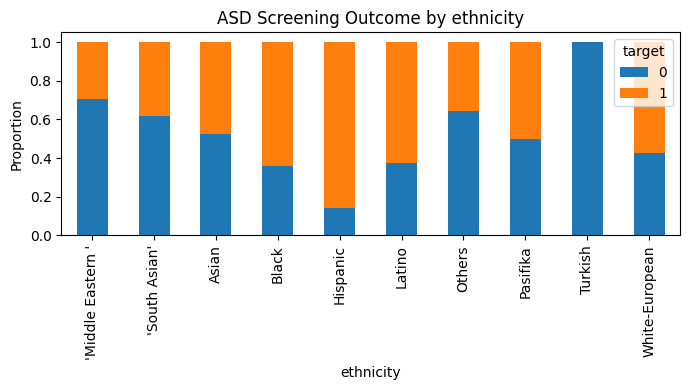

target,0,1
jaundice,,
no,0.509524,0.490476
yes,0.537500,0.462500


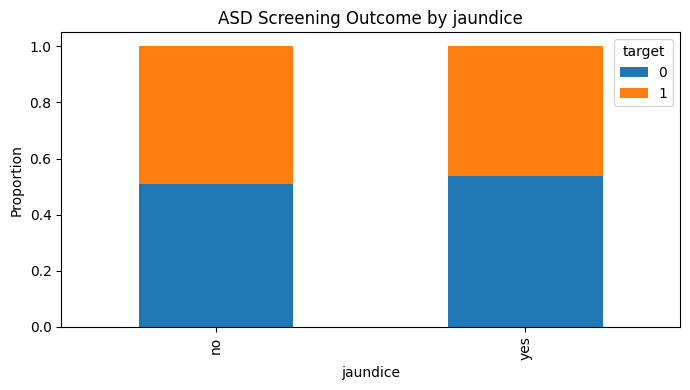

target,0,1
autism,,
no,0.506224,0.493776
yes,0.571429,0.428571


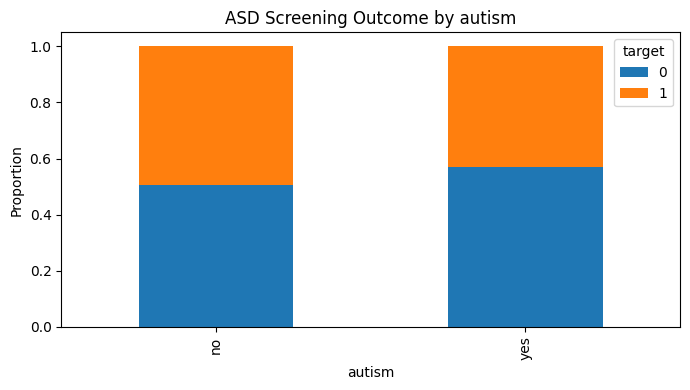

target,0,1
used_app_before,,
no,0.512545,0.487455
yes,0.636364,0.363636


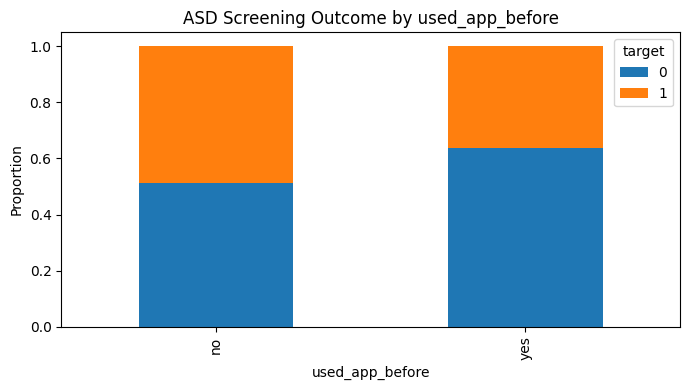

target,0,1
age_desc,,
'4-11 years',0.517241,0.482759


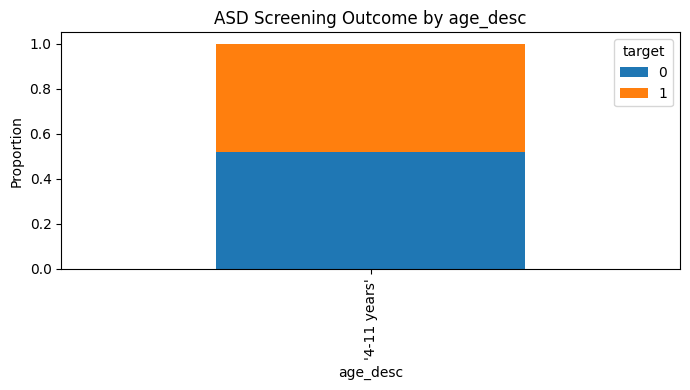

target,0,1
relation,,
'Health care professional',0.461538,0.538462
Parent,0.476415,0.523585
Relative,0.705882,0.294118
Self,0.750000,0.250000
self,0.000000,1.000000


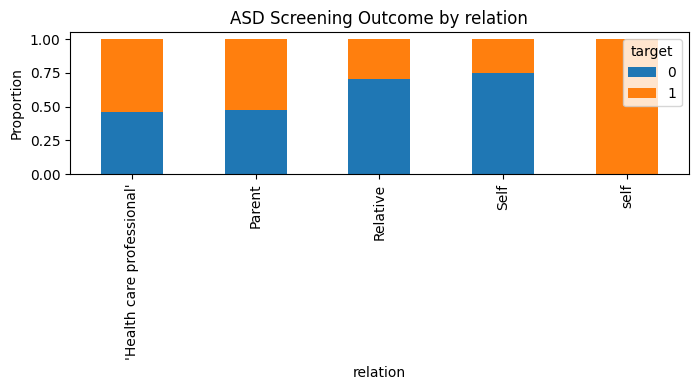

In [ ]:
for col in categorical_cols:
    if feature_df[col].nunique(dropna=True) <= 10:
        table = pd.crosstab(
            df_clean[col],
            df_clean["target"],
            normalize="index"
        )

        display(table)

        table.plot(
            kind="bar",
            stacked=True,
            figsize=(7,4)
        )

        plt.title(f"ASD Screening Outcome by {col}")
        plt.ylabel("Proportion")
        plt.tight_layout()
        plt.show()

## 15. Correlation Matrix

Correlation is interpreted as **association**, not causation.

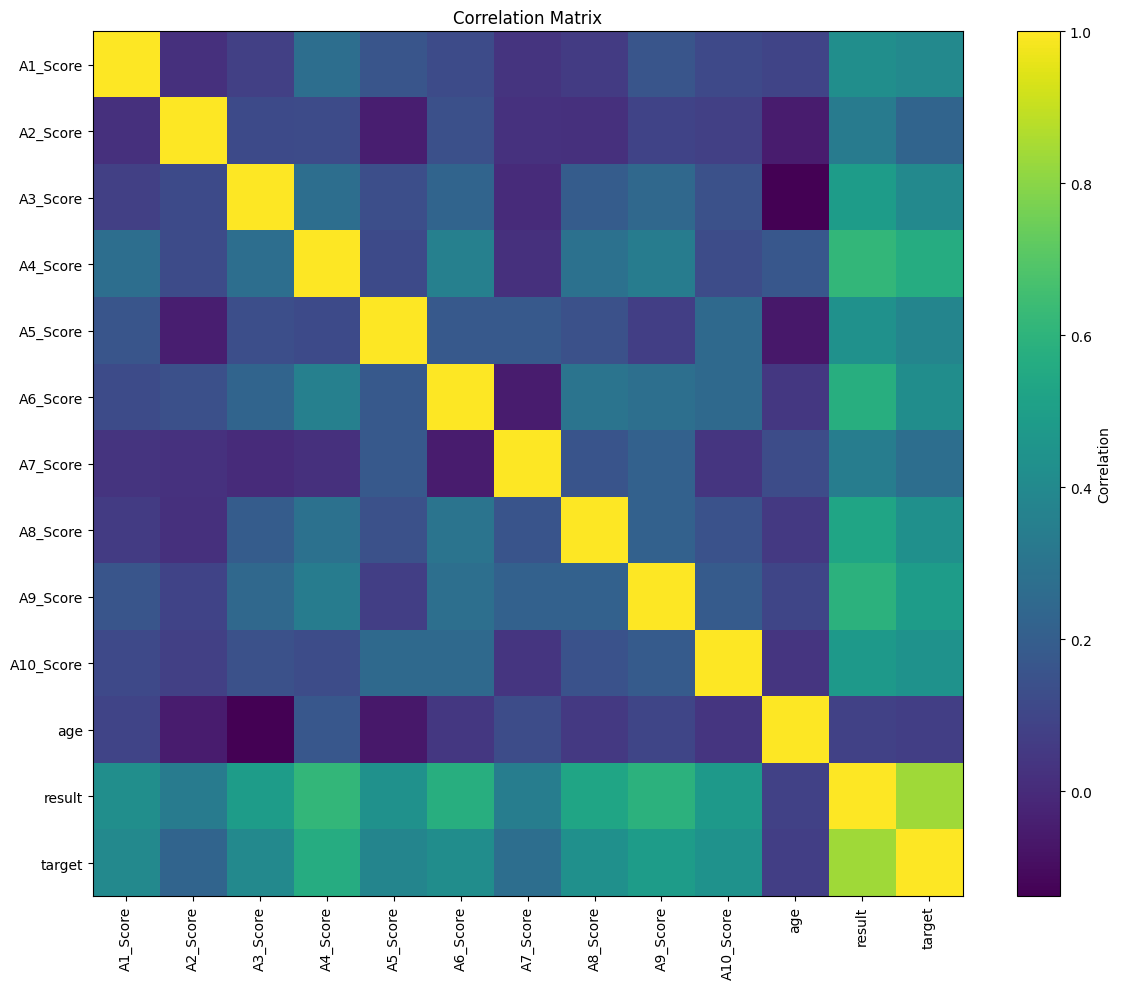

In [ ]:
numeric_for_corr = df_clean[
    list(dict.fromkeys(numeric_cols + ["target"]))
].copy()

numeric_for_corr = numeric_for_corr.apply(
    pd.to_numeric,
    errors="coerce"
)

corr = numeric_for_corr.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr, aspect="auto")
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("results/figures/correlation_matrix.png", bbox_inches="tight")
plt.show()

## 16. Domain-Derived Feature — Behavioural Positive Count

A total count of positive behavioural responses is useful for EDA. However, it may be closely related to the screening rule used to create the target. Therefore it is **not automatically included in the final model**.

In [ ]:
if behavior_cols:
    df_clean["behavior_positive_count"] = (
        df_clean[behavior_cols]
        .apply(pd.to_numeric, errors="coerce")
        .sum(axis=1)
    )

    display(
        df_clean[
            ["behavior_positive_count", "target"]
        ].head()
    )

,behavior_positive_count,target
0,5,0
1,5,0
2,5,0
3,4,0
4,10,1


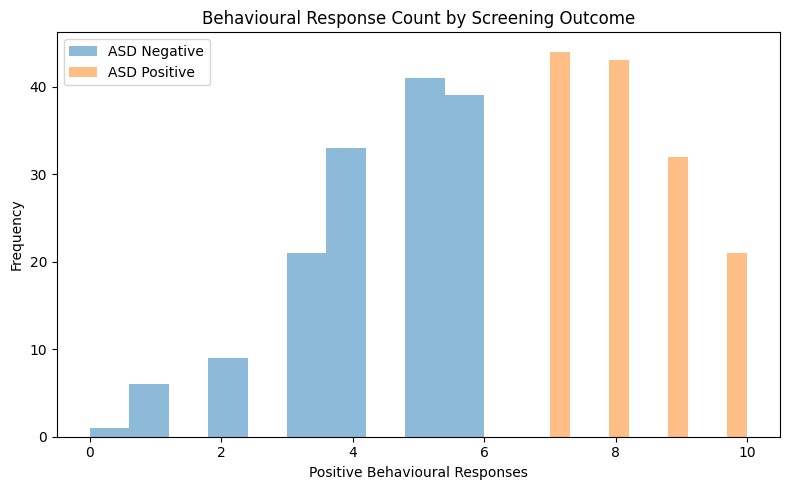

In [ ]:
if "behavior_positive_count" in df_clean.columns:
    plt.figure(figsize=(8,5))

    for cls, label in [
        (0, "ASD Negative"),
        (1, "ASD Positive")
    ]:
        subset = df_clean.loc[
            df_clean["target"] == cls,
            "behavior_positive_count"
        ]

        plt.hist(
            subset,
            alpha=0.5,
            label=label
        )

    plt.xlabel("Positive Behavioural Responses")
    plt.ylabel("Frequency")
    plt.title("Behavioural Response Count by Screening Outcome")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        "results/figures/behavior_count_distribution.png",
        bbox_inches="tight"
    )
    plt.show()

## 17. Age Binning

Age bands are created only if an `age` field exists. Adjust the bins if the observed age distribution suggests a better grouping.

In [ ]:
age_candidates = [
    col for col in feature_df.columns
    if col.lower() == "age"
]

if age_candidates:
    age_col = age_candidates[0]

    df_clean["age_group"] = pd.cut(
        pd.to_numeric(
            df_clean[age_col],
            errors="coerce"
        ),
        bins=[0, 5, 8, 12, np.inf],
        labels=[
            "Early childhood",
            "6-8",
            "9-12",
            "13+"
        ]
    )

    display(
        pd.crosstab(
            df_clean["age_group"],
            df_clean["target"],
            normalize="index"
        )
    )
else:
    print("No exact 'age' column detected.")

target,0,1
age_group,,
Early childhood,0.540741,0.459259
6-8,0.528736,0.471264
9-12,0.453125,0.546875


## 18. Target Leakage Investigation

Potential leakage occurs when a feature directly encodes or is derived from the same screening process used to define the target.

This notebook does **not automatically remove all fields containing the word `score`**, because `A1_Score`–`A10_Score` are legitimate questionnaire items. Instead, suspicious aggregate/result columns are identified for manual verification against the UCI metadata.

In [ ]:
possible_leakage = [
    col for col in feature_df.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "result",
            "total",
            "class"
        ]
    )
]

print("Possible aggregate / target-derived fields:")
print(possible_leakage)

display(asd.variables)

Possible aggregate / target-derived fields:
['result']


,name,role,type,demographic,description,units,missing_values
0,A1_Score,Feature,Integer,None,None,None,no
1,A2_Score,Feature,Integer, ,None,None,no
2,A3_Score,Feature,Integer,None,None,None,no
3,A4_Score,Feature,Integer,None,None,None,no
4,A5_Score,Feature,Integer,None,None,None,no
5,A6_Score,Feature,Integer,None,None,None,no
6,A7_Score,Feature,Integer,None,None,None,no
7,A8_Score,Feature,Integer,None,None,None,no
8,A9_Score,Feature,Integer,None,None,None,no
9,A10_Score,Feature,Integer,None,None,None,no


### Manual leakage decision

After reviewing the UCI variable definitions, add only **confirmed target-derived fields** to `LEAKAGE_FEATURES`.

For example, a total screening result used directly to assign the ASD class should be excluded from the leakage-controlled model.

In [ ]:
LEAKAGE_FEATURES = [
    # Example:
    # "result"
]

print("Confirmed leakage features to remove:", LEAKAGE_FEATURES)

Confirmed leakage features to remove: []


## 19. Prepare the Modelling Dataset

In [ ]:
X = df_clean.drop(
    columns=[
        target_name,
        "target",
        "behavior_positive_count",
        "age_group"
    ],
    errors="ignore"
).copy()

y = df_clean["target"].astype(int).copy()

X_leakage_controlled = X.drop(
    columns=LEAKAGE_FEATURES,
    errors="ignore"
)

print("Full feature shape:", X.shape)
print(
    "Leakage-controlled feature shape:",
    X_leakage_controlled.shape
)

Full feature shape: (290, 20)
Leakage-controlled feature shape: (290, 20)


## 20. Train/Test Split

The target is stratified so the class proportions are preserved.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_leakage_controlled,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training: (232, 20)
Testing: (58, 20)

Training target distribution:
target
0    0.517241
1    0.482759
Name: proportion, dtype: float64

Testing target distribution:
target
0    0.517241
1    0.482759
Name: proportion, dtype: float64


## 21. Preprocessing Pipeline

- Numeric: median imputation + standard scaling
- Categorical: most-frequent imputation + one-hot encoding

All transformations are fitted on training data only.

In [ ]:
numeric_features = (
    X_train
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'result']
Categorical: ['gender', 'ethnicity', 'jaundice', 'autism', 'country_of_res', 'used_app_before', 'age_desc', 'relation']


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (232, 81)
Processed testing shape: (58, 81)


## 22. Feature Selection — Mutual Information

Mutual Information is used as a filter-based selection method because it can identify both linear and nonlinear relationships between predictors and the binary target.

In [ ]:
mi = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=SEED
)

mi_df = pd.DataFrame({
    "Feature": feature_names,
    "Mutual_Information": mi
}).sort_values(
    "Mutual_Information",
    ascending=False
)

display(mi_df.head(20))

mi_df.to_csv(
    "results/tables/mutual_information_features.csv",
    index=False
)

,Feature,Mutual_Information
11,num__result,0.694712
2,num__A3_Score,0.146432
3,num__A4_Score,0.145896
7,num__A8_Score,0.114151
5,num__A6_Score,0.101642
4,num__A5_Score,0.099471
0,num__A1_Score,0.092380
9,num__A10_Score,0.080006
75,cat__used_app_before_yes,0.076770
80,cat__relation_Self,0.066809


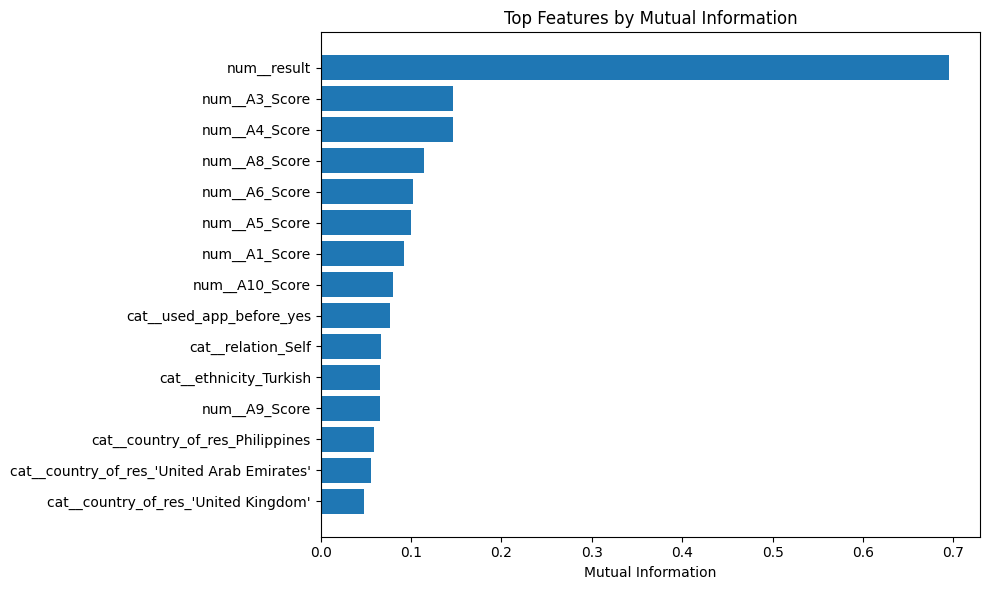

In [ ]:
top_mi = mi_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(
    top_mi["Feature"][::-1],
    top_mi["Mutual_Information"][::-1]
)
plt.xlabel("Mutual Information")
plt.title("Top Features by Mutual Information")
plt.tight_layout()
plt.savefig("results/figures/mutual_information.png", bbox_inches="tight")
plt.show()

## 23. Feature Selection — Recursive Feature Elimination (RFE)

RFE provides a wrapper-based comparison to Mutual Information.

In [ ]:
n_select = min(
    10,
    X_train_processed.shape[1]
)

rfe_model = LogisticRegression(
    max_iter=5000,
    random_state=SEED
)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=n_select
)

rfe.fit(
    X_train_processed,
    y_train
)

rfe_results = pd.DataFrame({
    "Feature": feature_names,
    "Selected": rfe.support_,
    "Rank": rfe.ranking_
}).sort_values("Rank")

display(rfe_results.head(20))

rfe_results.to_csv(
    "results/tables/rfe_features.csv",
    index=False
)

,Feature,Selected,Rank
0,num__A1_Score,True,1
1,num__A2_Score,True,1
2,num__A3_Score,True,1
3,num__A4_Score,True,1
4,num__A5_Score,True,1
6,num__A7_Score,True,1
7,num__A8_Score,True,1
8,num__A9_Score,True,1
11,num__result,True,1
9,num__A10_Score,True,1


## 24. Dimensionality Reduction — PCA

PCA is used for dimensionality reduction and exploratory visualization. It is not automatically used in the final model because individual feature interpretability is important in a healthcare screening context.

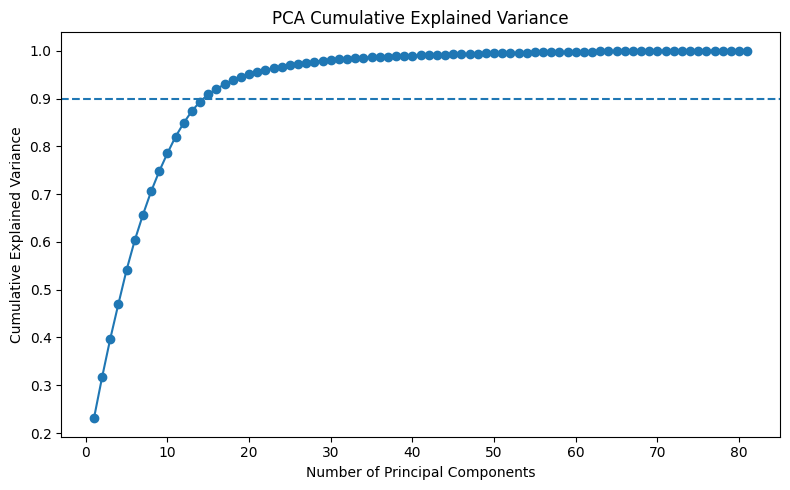

In [ ]:
pca_full = PCA()
pca_full.fit(X_train_processed)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(y=0.90, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.tight_layout()
plt.savefig("results/figures/pca_cumulative_variance.png", bbox_inches="tight")
plt.show()

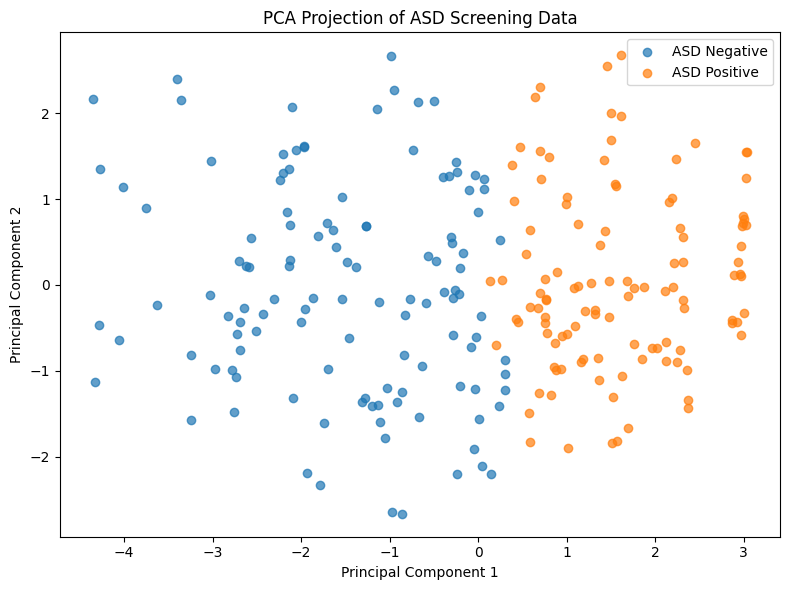

Variance explained by first 2 PCs: 0.3169


In [ ]:
pca2 = PCA(n_components=2, random_state=SEED)
X_pca = pca2.fit_transform(X_train_processed)

plt.figure(figsize=(8,6))

for cls, label in [
    (0, "ASD Negative"),
    (1, "ASD Positive")
]:
    idx = y_train.to_numpy() == cls

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of ASD Screening Data")
plt.legend()
plt.tight_layout()
plt.savefig("results/figures/pca_2d.png", bbox_inches="tight")
plt.show()

print(
    "Variance explained by first 2 PCs:",
    round(pca2.explained_variance_ratio_.sum(), 4)
)

## 25. Optional Visualization — t-SNE

t-SNE is used only as a supplementary visualization. Apparent clusters should not be interpreted as clinical subtypes.

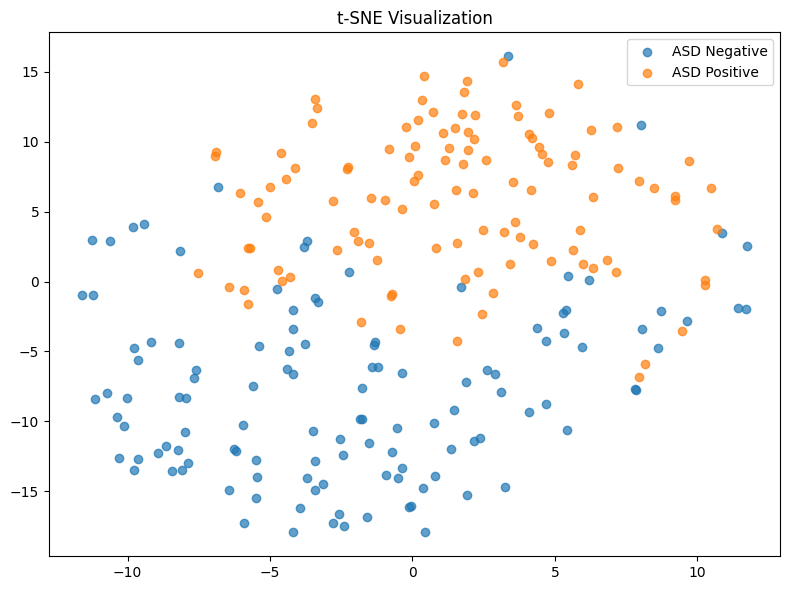

In [ ]:
if X_train_processed.shape[0] > 30:
    perplexity = min(30, max(5, (X_train_processed.shape[0] - 1) // 3))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=SEED,
        init="pca",
        learning_rate="auto"
    )

    X_tsne = tsne.fit_transform(
        X_train_processed
    )

    plt.figure(figsize=(8,6))

    for cls, label in [
        (0, "ASD Negative"),
        (1, "ASD Positive")
    ]:
        idx = y_train.to_numpy() == cls

        plt.scatter(
            X_tsne[idx,0],
            X_tsne[idx,1],
            label=label,
            alpha=0.7
        )

    plt.title("t-SNE Visualization")
    plt.legend()
    plt.tight_layout()
    plt.savefig("results/figures/tsne_2d.png", bbox_inches="tight")
    plt.show()
else:
    print("Dataset too small for a useful t-SNE visualization.")

# STEP 4 — Model Implementation & Comparison

Deep learning is intentionally not used because the dataset contains only a few hundred observations. Logistic Regression, Decision Tree, Random Forest, XGBoost, and SVM are better justified for this small tabular classification problem.

## 26. Candidate Models

In [ ]:
models = {
    "Dummy": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=SEED
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=SEED,
        eval_metric="logloss"
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=SEED
    )
}

## 27. Stratified 5-Fold Cross-Validation

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        error_score=np.nan
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": np.nanmean(scores["test_accuracy"]),
        "CV Precision": np.nanmean(scores["test_precision"]),
        "CV Recall": np.nanmean(scores["test_recall"]),
        "CV F1": np.nanmean(scores["test_f1"]),
        "CV ROC-AUC": np.nanmean(scores["test_roc_auc"]),
        "ROC-AUC SD": np.nanstd(scores["test_roc_auc"]),
        "CV PR-AUC": np.nanmean(scores["test_pr_auc"])
    })

cv_df = pd.DataFrame(cv_results)

display(
    cv_df.sort_values(
        "CV ROC-AUC",
        ascending=False
    )
)

cv_df.to_csv(
    "results/tables/cross_validation_results.csv",
    index=False
)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,ROC-AUC SD,CV PR-AUC
1,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,1.000000
2,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,1.000000
4,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,1.000000
3,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,4.965068e-17,1.000000
5,SVM,0.974191,0.959532,0.990909,0.974215,0.999242,1.515152e-03,0.999242
0,Dummy,0.517299,0.000000,0.000000,0.000000,0.500000,0.000000e+00,0.482701


## 28. Hyperparameter Tuning — Logistic Regression

In [ ]:
log_pipe = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED
        )
    )
])

log_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

log_search = GridSearchCV(
    log_pipe,
    log_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

log_search.fit(
    X_train,
    y_train
)

print("Best Logistic Regression parameters:")
print(log_search.best_params_)
print("Best CV ROC-AUC:", log_search.best_score_)

Best Logistic Regression parameters:
{'model__C': 0.01}
Best CV ROC-AUC: 1.0


## 29. Hyperparameter Tuning — Random Forest

In [ ]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced",
            random_state=SEED
        )
    )
])

rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 3, 5, 8],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = GridSearchCV(
    rf_pipe,
    rf_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_search.fit(
    X_train,
    y_train
)

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print("Best CV ROC-AUC:", rf_search.best_score_)

Best Random Forest parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV ROC-AUC: 1.0


## 30. Select the Better Tuned Candidate

This cell compares the tuned Logistic Regression and Random Forest models by CV ROC-AUC. You may later expand tuning to XGBoost or SVM if desired.

In [ ]:
if rf_search.best_score_ >= log_search.best_score_:
    best_model = rf_search.best_estimator_
    best_model_name = "Random Forest"
    best_params = rf_search.best_params_
    best_cv_auc = rf_search.best_score_
else:
    best_model = log_search.best_estimator_
    best_model_name = "Logistic Regression"
    best_params = log_search.best_params_
    best_cv_auc = log_search.best_score_

print("Selected model:", best_model_name)
print("CV ROC-AUC:", best_cv_auc)
print("Parameters:", best_params)

Selected model: Random Forest
CV ROC-AUC: 1.0
Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


## 31. Final Test Evaluation

In [ ]:
best_model.fit(
    X_train,
    y_train
)

y_pred = best_model.predict(
    X_test
)

if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(
        X_test
    )[:,1]
else:
    y_prob = best_model.decision_function(
        X_test
    )

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0,1]
)

tn, fp, fn, tp = cm.ravel()

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)

test_metrics = {
    "Model": best_model_name,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall/Sensitivity": recall_score(y_test, y_pred, zero_division=0),
    "Specificity": specificity,
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob),
    "False Negative Rate": (
        fn / (fn + tp)
        if (fn + tp) > 0
        else np.nan
    ),
    "False Positive Rate": (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )
}

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

display(test_metrics_df)

test_metrics_df.to_csv(
    "results/tables/final_test_metrics.csv",
    index=False
)

,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1,ROC-AUC,PR-AUC,False Negative Rate,False Positive Rate
0,Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0


## 32. Confusion Matrix

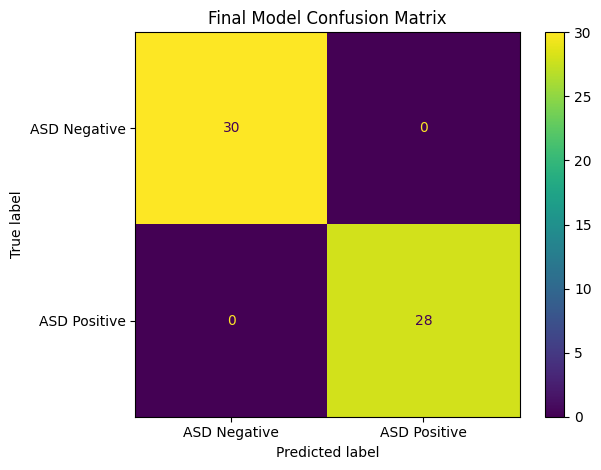

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "ASD Negative",
        "ASD Positive"
    ]
)

plt.title("Final Model Confusion Matrix")
plt.tight_layout()
plt.savefig("results/figures/final_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 33. ROC Curve

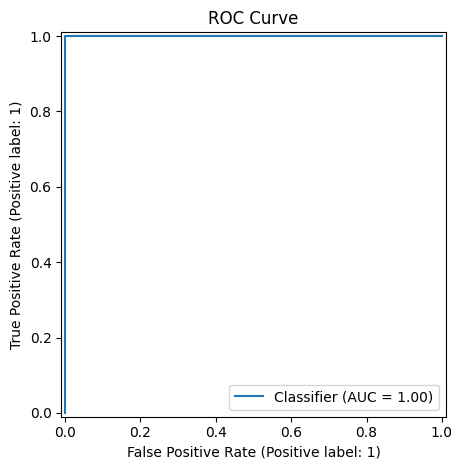

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.tight_layout()
plt.savefig("results/figures/final_roc_curve.png", bbox_inches="tight")
plt.show()

## 34. Precision-Recall Curve

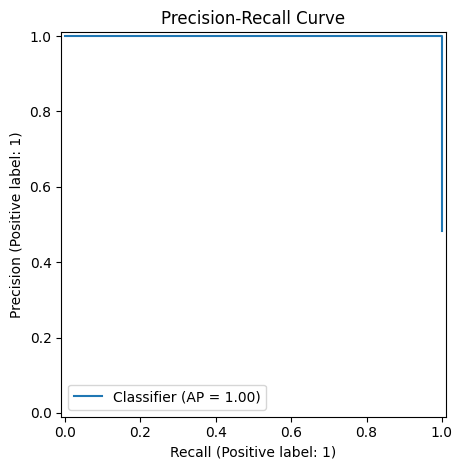

In [ ]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig("results/figures/final_precision_recall_curve.png", bbox_inches="tight")
plt.show()

## 35. Save Model and Configuration

In [ ]:
joblib.dump(
    best_model,
    "models/final_asd_classifier.joblib"
)

config = {
    "random_seed": SEED,
    "test_size": 0.20,
    "cv_folds": 5,
    "target": target_name,
    "best_model": best_model_name,
    "best_parameters": best_params,
    "best_cv_roc_auc": float(best_cv_auc),
    "leakage_features_removed": LEAKAGE_FEATURES
}

with open(
    "configs/model_config.json",
    "w"
) as f:
    json.dump(
        config,
        f,
        indent=4
    )

print("Model and configuration saved.")

Model and configuration saved.


# STEP 5 — Critical Thinking, Explainable AI & Bias Auditing

## 36. Overfitting / Generalisation Check

In [ ]:
if hasattr(best_model, "predict_proba"):
    train_prob = best_model.predict_proba(
        X_train
    )[:,1]
else:
    train_prob = best_model.decision_function(
        X_train
    )

train_auc = roc_auc_score(
    y_train,
    train_prob
)

test_auc = roc_auc_score(
    y_test,
    y_prob
)

generalisation_gap = (
    train_auc - test_auc
)

print("Training ROC-AUC:", train_auc)
print("Testing ROC-AUC:", test_auc)
print("Generalisation Gap:", generalisation_gap)

Training ROC-AUC: 1.0
Testing ROC-AUC: 1.0
Generalisation Gap: 0.0


## 37. Explainability

For a tree-based final model, SHAP TreeExplainer is used. If Logistic Regression is selected, model coefficients are used as the primary global interpretation and SHAP may be applied with a generic explainer.

In [ ]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_classifier = best_model.named_steps["model"]

X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

transformed_names = fitted_preprocessor.get_feature_names_out()

print("Transformed feature count:", len(transformed_names))

Transformed feature count: 81


### 37.1 Model-Based Feature Importance / Coefficients

,Feature,Importance
11,num__result,0.391660
3,num__A4_Score,0.092862
8,num__A9_Score,0.063396
9,num__A10_Score,0.056639
7,num__A8_Score,0.047385
2,num__A3_Score,0.041057
0,num__A1_Score,0.039240
5,num__A6_Score,0.038701
4,num__A5_Score,0.026664
6,num__A7_Score,0.021851


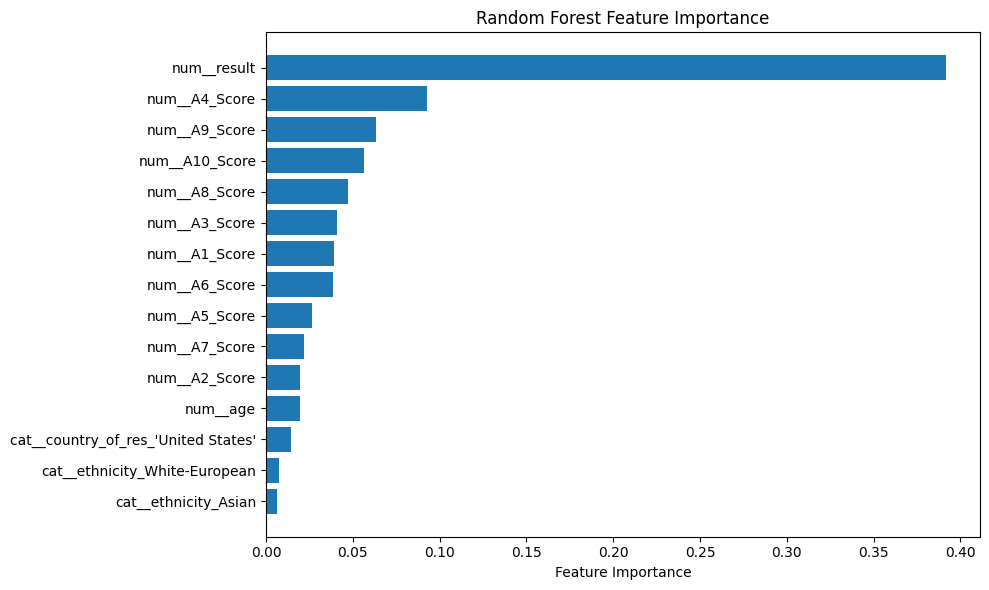

In [ ]:
if hasattr(fitted_classifier, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": transformed_names,
        "Importance": fitted_classifier.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    )

    display(importance_df.head(15))

    importance_df.to_csv(
        "results/tables/model_feature_importance.csv",
        index=False
    )

    top_features = importance_df.head(15)

    plt.figure(figsize=(10,6))
    plt.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1]
    )
    plt.xlabel("Feature Importance")
    plt.title(f"{best_model_name} Feature Importance")
    plt.tight_layout()
    plt.savefig(
        "results/figures/model_feature_importance.png",
        bbox_inches="tight"
    )
    plt.show()

elif hasattr(fitted_classifier, "coef_"):

    coef_df = pd.DataFrame({
        "Feature": transformed_names,
        "Coefficient": fitted_classifier.coef_[0]
    })

    coef_df["Absolute_Coefficient"] = coef_df[
        "Coefficient"
    ].abs()

    coef_df = coef_df.sort_values(
        "Absolute_Coefficient",
        ascending=False
    )

    display(coef_df.head(15))

    coef_df.to_csv(
        "results/tables/logistic_coefficients.csv",
        index=False
    )

else:
    print("No direct model-based feature importance available.")

### 37.2 SHAP

SHAP output shape: (58, 81, 2)


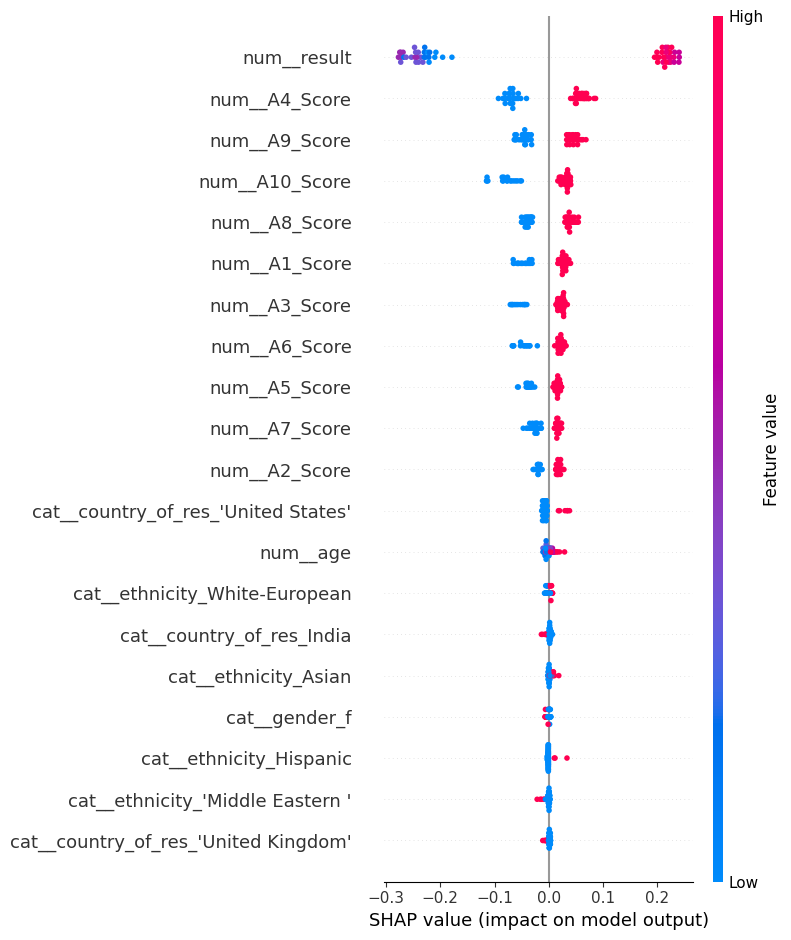

In [ ]:
try:
    if hasattr(fitted_classifier, "feature_importances_"):
        explainer = shap.TreeExplainer(
            fitted_classifier
        )

        shap_values = explainer(
            X_test_transformed
        )

        print("SHAP output shape:", shap_values.values.shape)

        if len(shap_values.values.shape) == 3:
            shap.summary_plot(
                shap_values.values[:, :, 1],
                X_test_transformed,
                feature_names=transformed_names,
                show=False
            )
        else:
            shap.summary_plot(
                shap_values.values,
                X_test_transformed,
                feature_names=transformed_names,
                show=False
            )

        plt.tight_layout()
        plt.savefig(
            "results/figures/shap_summary.png",
            bbox_inches="tight"
        )
        plt.show()

    else:
        background = X_train_transformed[:min(100, len(X_train_transformed))]

        explainer = shap.Explainer(
            fitted_classifier.predict_proba,
            background
        )

        sample = X_test_transformed[:min(50, len(X_test_transformed))]
        shap_values = explainer(sample)

        if len(shap_values.values.shape) == 3:
            shap.summary_plot(
                shap_values.values[:, :, 1],
                sample,
                feature_names=transformed_names,
                show=False
            )
        else:
            shap.summary_plot(
                shap_values.values,
                sample,
                feature_names=transformed_names,
                show=False
            )

        plt.tight_layout()
        plt.savefig(
            "results/figures/shap_summary.png",
            bbox_inches="tight"
        )
        plt.show()

except Exception as e:
    print("SHAP could not be generated automatically.")
    print("Reason:", e)
    print(
        "Use the model-based importance/coefficient section above "
        "and inspect the SHAP package version if needed."
    )

## 38. Partial Dependence Plot

PDP is generated only for suitable numeric predictors.

In [ ]:
if numeric_features:
    try:
        PartialDependenceDisplay.from_estimator(
            best_model,
            X_train,
            features=[numeric_features[0]]
        )

        plt.tight_layout()
        plt.savefig(
            "results/figures/partial_dependence.png",
            bbox_inches="tight"
        )
        plt.show()

    except Exception as e:
        print("PDP could not be generated for the selected feature.")
        print("Reason:", e)
else:
    print("No numeric predictor available for PDP.")

PDP could not be generated for the selected feature.
Reason: cannot reshape array of size 1 into shape (2)


## 39. Bias Audit — Sensitive Group Detection

The notebook searches for gender/sex variables. If found, subgroup performance is calculated.

In [ ]:
sensitive_candidates = [
    col for col in X_test.columns
    if "gender" in col.lower()
    or col.lower() == "sex"
]

print("Sensitive group candidates:", sensitive_candidates)

Sensitive group candidates: ['gender']


In [ ]:
def subgroup_metrics(data):

    results = []

    for group, subset in data.groupby("group"):

        if len(subset) < 5:
            results.append({
                "Group": group,
                "N": len(subset),
                "Recall": np.nan,
                "Specificity": np.nan,
                "FPR": np.nan,
                "FNR": np.nan,
                "Selection_Rate": np.nan,
                "Note": "Too few observations for stable interpretation"
            })
            continue

        y_true = subset["actual"]
        y_hat = subset["prediction"]

        cm = confusion_matrix(
            y_true,
            y_hat,
            labels=[0,1]
        )

        tn, fp, fn, tp = cm.ravel()

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

        fnr = (
            fn / (fn + tp)
            if (fn + tp) > 0
            else np.nan
        )

        selection_rate = y_hat.mean()

        results.append({
            "Group": group,
            "N": len(subset),
            "Recall": recall,
            "Specificity": specificity,
            "FPR": fpr,
            "FNR": fnr,
            "Selection_Rate": selection_rate,
            "Note": ""
        })

    return pd.DataFrame(results)

### 39.1 Gender / Sex Audit

In [ ]:
if sensitive_candidates:
    sensitive_col = sensitive_candidates[0]

    audit = pd.DataFrame({
        "actual": y_test.values,
        "prediction": y_pred,
        "probability": y_prob,
        "group": X_test[sensitive_col].values
    })

    gender_audit = subgroup_metrics(audit)
    display(gender_audit)

    gender_audit.to_csv(
        "results/tables/gender_fairness_audit.csv",
        index=False
    )

else:
    print("No gender/sex variable detected.")

,Group,N,Recall,Specificity,FPR,FNR,Selection_Rate,Note
0,f,16,1.0,1.0,0.0,0.0,0.4375,
1,m,42,1.0,1.0,0.0,0.0,0.5000,


## 40. Fairness Metrics

For medical screening, fairness metrics should be interpreted cautiously. Demographic parity does not imply equal underlying prevalence, so equal opportunity and false-negative gaps are often more relevant operationally.

In [ ]:
if sensitive_candidates and len(gender_audit) >= 2:

    valid = gender_audit.dropna(
        subset=[
            "Recall",
            "FPR",
            "Selection_Rate"
        ]
    )

    if len(valid) >= 2:

        demographic_parity_difference = (
            valid["Selection_Rate"].max()
            -
            valid["Selection_Rate"].min()
        )

        disparate_impact_ratio = (
            valid["Selection_Rate"].min()
            /
            valid["Selection_Rate"].max()
            if valid["Selection_Rate"].max() > 0
            else np.nan
        )

        equal_opportunity_difference = (
            valid["Recall"].max()
            -
            valid["Recall"].min()
        )

        tpr_gap = (
            valid["Recall"].max()
            -
            valid["Recall"].min()
        )

        fpr_gap = (
            valid["FPR"].max()
            -
            valid["FPR"].min()
        )

        fairness_summary = pd.DataFrame({
            "Metric": [
                "Demographic Parity Difference",
                "Disparate Impact Ratio",
                "Equal Opportunity Difference",
                "TPR Gap",
                "FPR Gap"
            ],
            "Value": [
                demographic_parity_difference,
                disparate_impact_ratio,
                equal_opportunity_difference,
                tpr_gap,
                fpr_gap
            ]
        })

        display(fairness_summary)

        fairness_summary.to_csv(
            "results/tables/fairness_summary.csv",
            index=False
        )

    else:
        print(
            "Not enough stable subgroup metrics "
            "to calculate fairness gaps."
        )

,Metric,Value
0,Demographic Parity Difference,0.0625
1,Disparate Impact Ratio,0.8750
2,Equal Opportunity Difference,0.0000
3,TPR Gap,0.0000
4,FPR Gap,0.0000


## 41. Age Fairness Audit

In [ ]:
age_cols = [
    c for c in X_test.columns
    if c.lower() == "age"
]

if age_cols:
    age_name = age_cols[0]

    age_numeric = pd.to_numeric(
        X_test[age_name],
        errors="coerce"
    )

    age_group = pd.cut(
        age_numeric,
        bins=[
            -np.inf,
            5,
            8,
            12,
            np.inf
        ],
        labels=[
            "<=5",
            "6-8",
            "9-12",
            "13+"
        ]
    )

    age_audit = pd.DataFrame({
        "actual": y_test.values,
        "prediction": y_pred,
        "probability": y_prob,
        "group": age_group.values
    }).dropna()

    age_fairness = subgroup_metrics(
        age_audit
    )

    display(age_fairness)

    age_fairness.to_csv(
        "results/tables/age_fairness_audit.csv",
        index=False
    )

else:
    print("No exact age column detected.")

,Group,N,Recall,Specificity,FPR,FNR,Selection_Rate,Note
0,<=5,24,1.0,1.0,0.0,0.0,0.375000,
1,6-8,20,1.0,1.0,0.0,0.0,0.500000,
2,9-12,14,1.0,1.0,0.0,0.0,0.642857,
3,13+,0,NaN,NaN,NaN,NaN,NaN,Too few observations for stable interpretation


## 42. Target Leakage Experiment Template

Run the modelling pipeline twice:

1. **Full-feature model**
2. **Leakage-controlled model**

Record the comparison below after confirming which variable(s), if any, directly encode the screening outcome.

In [ ]:
leakage_experiment_template = pd.DataFrame({
    "Experiment": [
        "Full Feature Model",
        "Leakage-Controlled Model",
        "Reduced / Selected Feature Model"
    ],
    "Features": [
        "All supplied features",
        "Confirmed target-derived variables removed",
        "Selected leakage-controlled features"
    ],
    "ROC_AUC": [np.nan, np.nan, np.nan],
    "Recall": [np.nan, np.nan, np.nan],
    "Notes": ["", "", ""]
})

display(leakage_experiment_template)

leakage_experiment_template.to_csv(
    "results/tables/leakage_experiment_template.csv",
    index=False
)

,Experiment,Features,ROC_AUC,Recall,Notes
0,Full Feature Model,All supplied features,NaN,NaN,
1,Leakage-Controlled Model,Confirmed target-derived variables removed,NaN,NaN,
2,Reduced / Selected Feature Model,Selected leakage-controlled features,NaN,NaN,
